In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
# Load dataset
housing=fetch_california_housing()

data = pd.DataFrame(housing.data,
columns=housing.feature_names)
data["Price"] = housing.target

In [4]:
# Select one feature
x = data[['AveRooms']].values
y = data['Price'].values

In [5]:
# Split data
x_train, x_test,y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [8]:
# Feature Scaling
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [36]:
w = 0
b = 0
learning_rate = 0.051

epochs = 1000
n = len(x_train_scaled)
cost_history = []
for i in range(epochs):
    y_pred = w * x_train_scaled.flatten() + b
    dw = (1/n) * np.sum((y_pred - y_train ) * x_train_scaled.flatten())
    db = (1/n) * np.sum(y_pred - y_train)
    w = w - learning_rate * dw
    b = b - learning_rate * db
    if i % 100 == 0:
        cost = (1/(2*n)) * np.sum((y_pred - y_train) ** 2)
        cost_history.append(cost)
        print(f"Epoch {i}, Cost = {cost:.4f}")

y_pred_gd = w * x_test_scaled.flatten() + b

Epoch 0, Cost = 2.8149
Epoch 100, Cost = 0.6517
Epoch 200, Cost = 0.6516
Epoch 300, Cost = 0.6516
Epoch 400, Cost = 0.6516
Epoch 500, Cost = 0.6516
Epoch 600, Cost = 0.6516
Epoch 700, Cost = 0.6516
Epoch 800, Cost = 0.6516
Epoch 900, Cost = 0.6516


In [37]:
print ("Gradient Descent")
print ("----------------")
print ("Weight:",w)
print ("Bias:",b)
print ("MSE:",mean_squared_error(y_test,y_pred_gd))
print ("R2 Score:", r2_score(y_test,y_pred_gd))      


Gradient Descent
----------------
Weight: 0.18323881713491472
Bias: 2.071946937378872
MSE: 1.2923314440807299
R2 Score: 0.013795337532284901


In [38]:
#-------------------------
#Normal Equation
#------------------------
x_train_ne = np.c_[np.ones((len(x_train),1)),x_train]
x_test_ne = np.c_[np.ones((len(x_test),1)),x_test]
theta = np.linalg.inv(x_train_ne.T @ x_train_ne) @ x_train_ne.T @ y_train
y_pred_ne = x_test_ne @ theta

In [39]:
print ("\n Normal Equation")
print ("----------------")
print ("Intercept:",theta[0])
print ("Slope:",theta[1])
print ("MSE:",mean_squared_error(y_test,y_pred_ne))
print ("R2 Score:", r2_score(y_test,y_pred_ne))      



 Normal Equation
----------------
Intercept: 1.6547622685968417
Slope: 0.07675558963126736
MSE: 1.2923314440807299
R2 Score: 0.013795337532284901


In [40]:
#-------------------------------
#Sort values for smooth regression line
#-------------------------------
sort_axis = np.argsort(x_test.flatten())
x_sorted = x_test[sort_axis]
y_pred_ne_sorted = y_pred_ne[sort_axis]

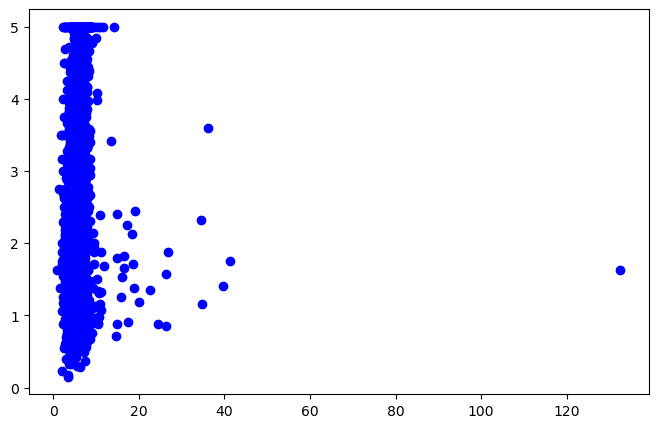

In [41]:
#-------------------------
#Regression Line Visualization
#------------------------
#Sort x values for a smooth line
index = np.argsort(x_test.flatten())
plt.figure(figsize=(8,5))
#Scatter plot
plt.scatter(x_test,y_test, color='blue',label='Actual Data')

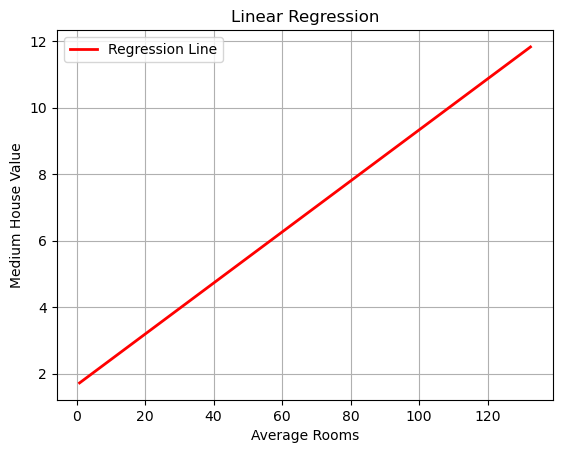

In [42]:
# Regression
plt.plot(
    x_test.flatten()[index],
    y_pred_ne[index],
    color='red',
    linewidth=2,
    label='Regression Line')
plt.title("Linear Regression")
plt.xlabel("Average Rooms")
plt.ylabel("Medium House Value")
plt.legend()
plt.grid(True)
plt.show()




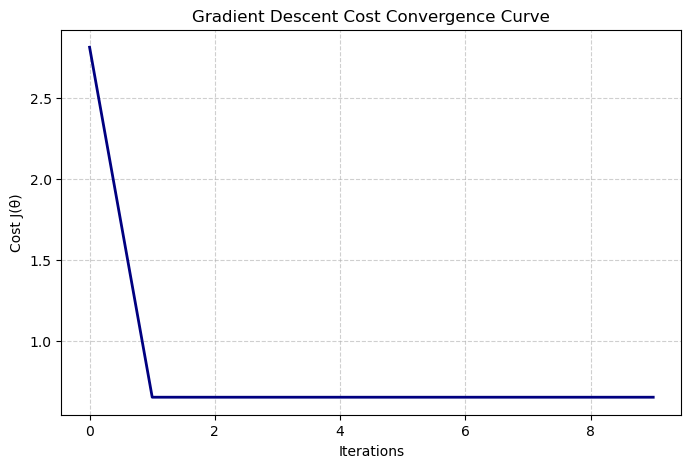

In [44]:
#-------------------------
#Cost Convergence Curve
#------------------------
plt.figure(figsize=(8,5))
plt.plot(cost_history,color='navy',linewidth=2)
plt.title('Gradient Descent Cost Convergence Curve')
plt.xlabel('Iterations')
plt.ylabel('Cost J(θ)')
plt.grid(True, linestyle='--' , alpha=0.6)
plt.show()